# Supplement Sale Visualisation

Business Goal: Understand what drives revenue in supplement sales and identify opportunities to increase profit. 

Key Questions 
1. Which categories/ products generate the most revenue?
2. How do discounts affect sales and profit?
3. Which platform performs best?
4. Are returns affecting profits?
5. How does revenue change over time?

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("Supplement_Sales_Weekly_Cleaned.csv")
data.head()

,Unnamed: 0,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Return Rate,Monthly,Net Revenue
0,0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,0.013986,2020-01,4511.0988
1,1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,0.000000,2020-01,5908.8900
2,2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,0.000000,2020-01,2078.5100
3,3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,0.000000,2020-01,2249.8000
4,4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,0.019108,2020-01,5488.9825


# 1. Which categories makes the most revenue?

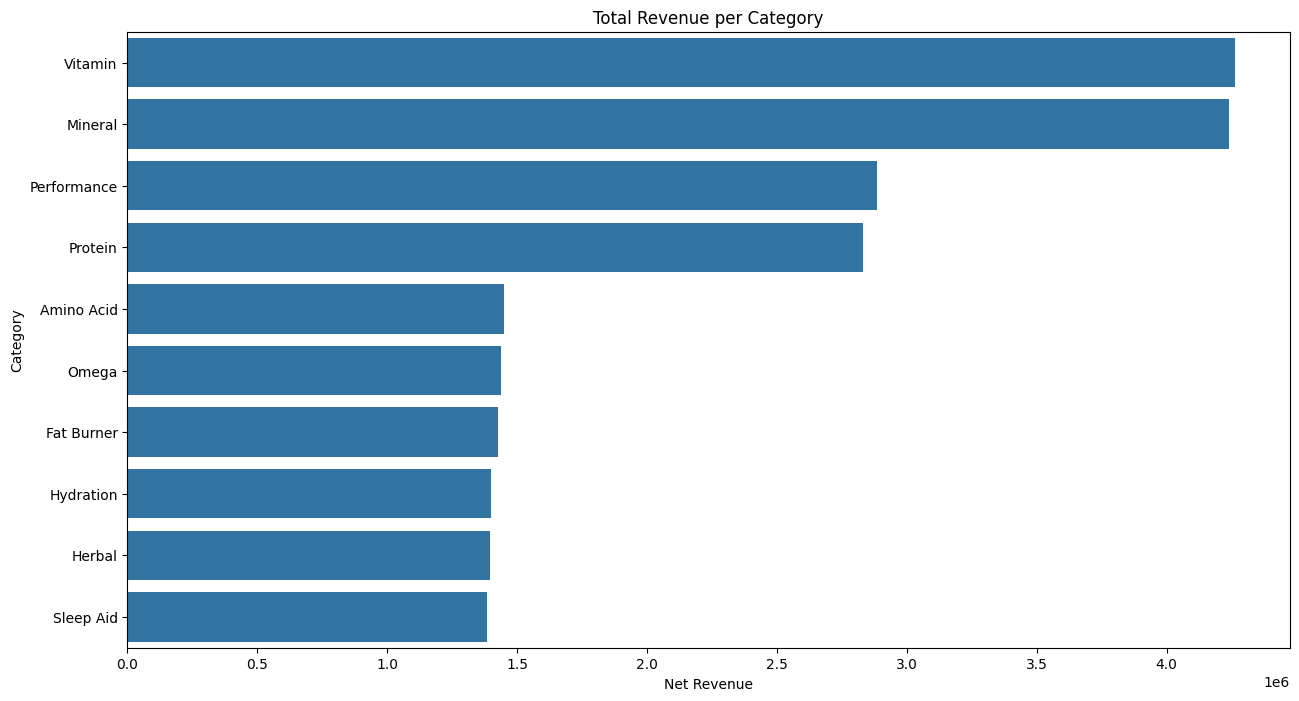

In [7]:
category_revenue = data.groupby('Category')['Net Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(15,8))
sns.barplot(x=category_revenue.values, y=category_revenue.index)
plt.title("Total Revenue per Category")
plt.xlabel("Net Revenue")
plt.ylabel("Category")
plt.show()


Insight: 
Vitamin and mineral dominate revenue, meaning the business is heavily dependent on these supplements. 

Decision:
Focus marketing on Vitamins, Minerals, Protein and Performance. 

# 2. Best selling product

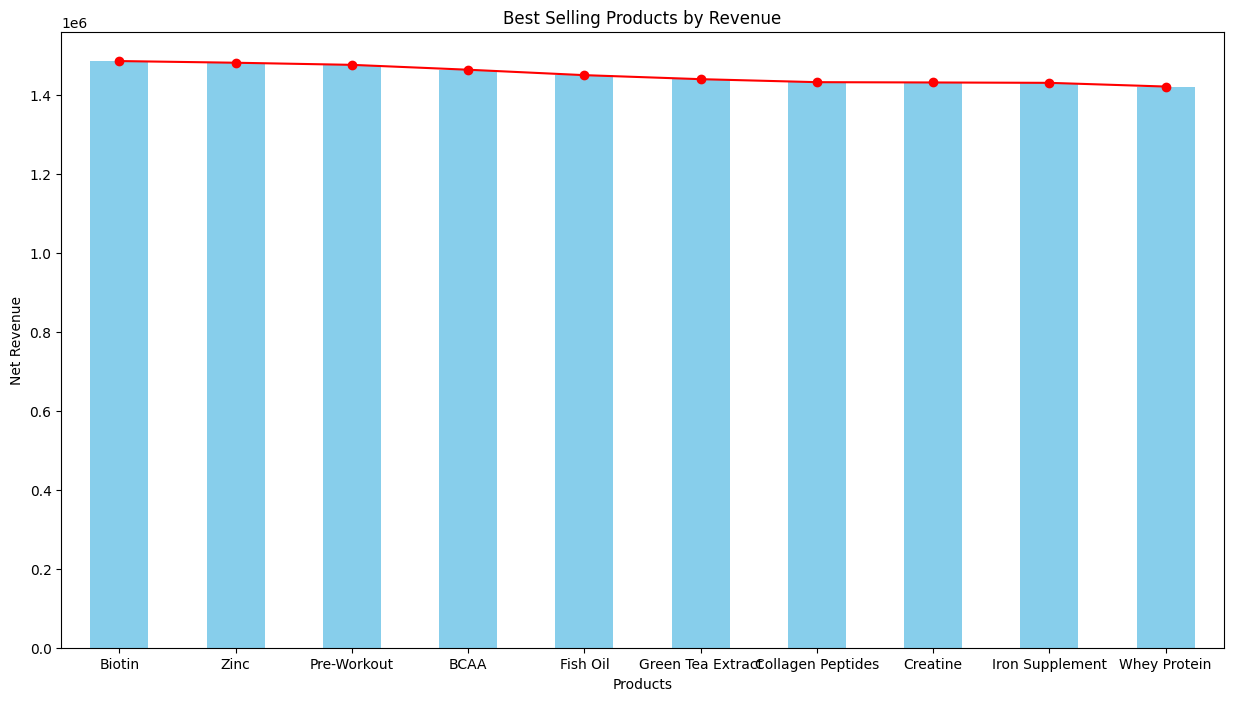

In [16]:
best_products = data.groupby("Product Name")["Revenue"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(15,8))
best_products.plot(kind='bar', ax=ax, color='skyblue', label='Revenue')
best_products.plot(kind='line', ax=ax, color='red', marker='o', label='Line Trend')
plt.title("Best Selling Products by Revenue")
plt.ylabel("Net Revenue")
plt.xlabel("Products")
plt.show()

Insight: Biotin generates a large share of revenue making it the top selling product, even though the other products are closely contributing too. 

Decision: Prioritise stock and ads for all these top products. 

# 3. Discount vs Revenue

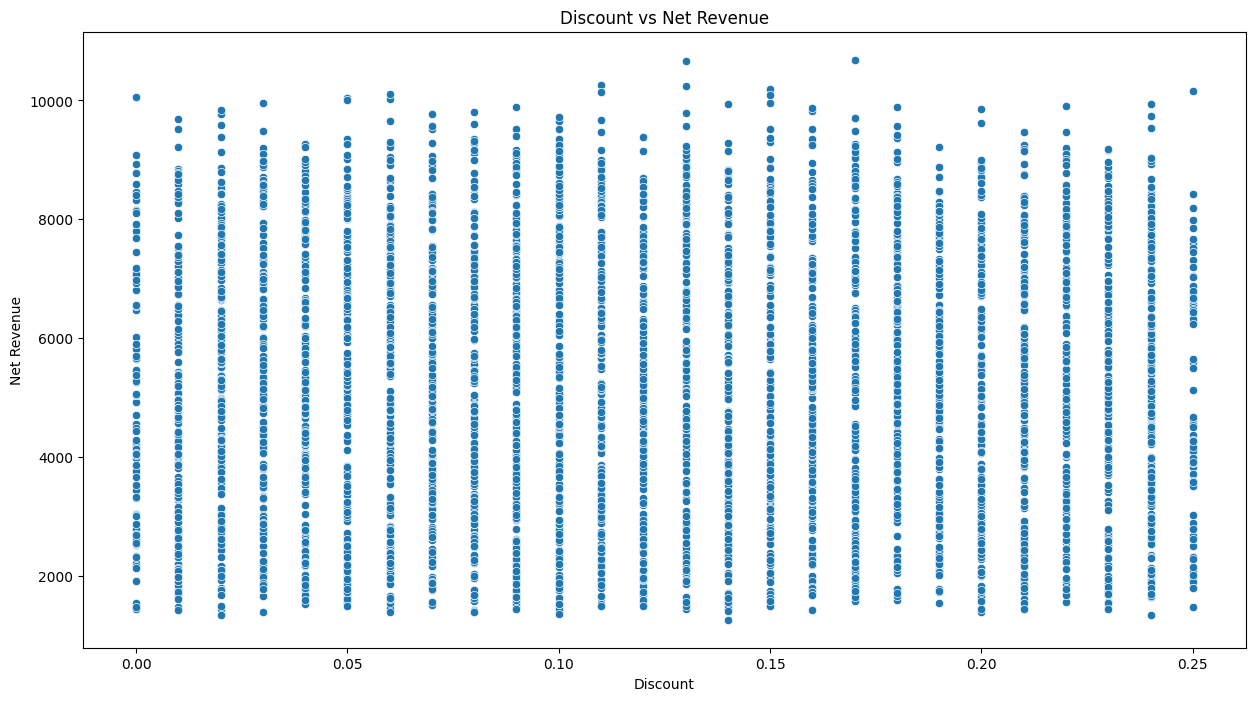

In [17]:
plt.figure(figsize=(15,8))
sns.scatterplot(x="Discount", y="Net Revenue", data=data)
plt.title("Discount vs Net Revenue")
plt.xlabel("Discount")
plt.ylabel("Net Revenue")
plt.show()

Insight: Higher discount leads to less revenue, however with some controlled discount there is still some revenue made from them. 

Decision: Reduce unnecessary high discounts but keep low discounts to generate more revenue. 

# 4. Platform Performance

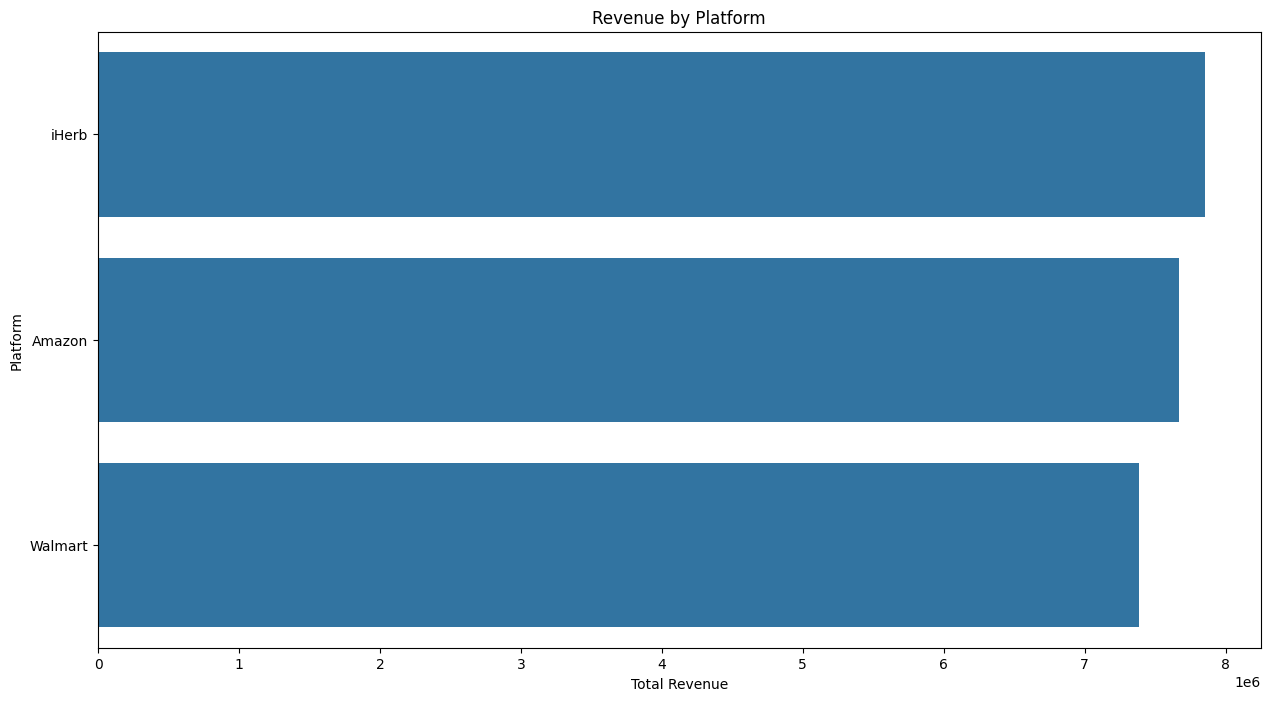

In [23]:
platform_performance = (
    data.groupby("Platform")
    .agg({
        "Units Sold": "sum",
        "Net Revenue": "sum",
        "Revenue": "sum"
    })
    .reset_index()
    .sort_values(by="Revenue", ascending=False)
)

plt.figure(figsize=(15,8))
sns.barplot(data=platform_performance, x="Revenue", y="Platform")
plt.title("Revenue by Platform")
plt.xlabel("Total Revenue")
plt.ylabel("Platform")
plt.show()

Insight: iHerb outperform other platforms. 

Decision: Invest more in iHerb than Walmart. 

# 5. Returns Impact

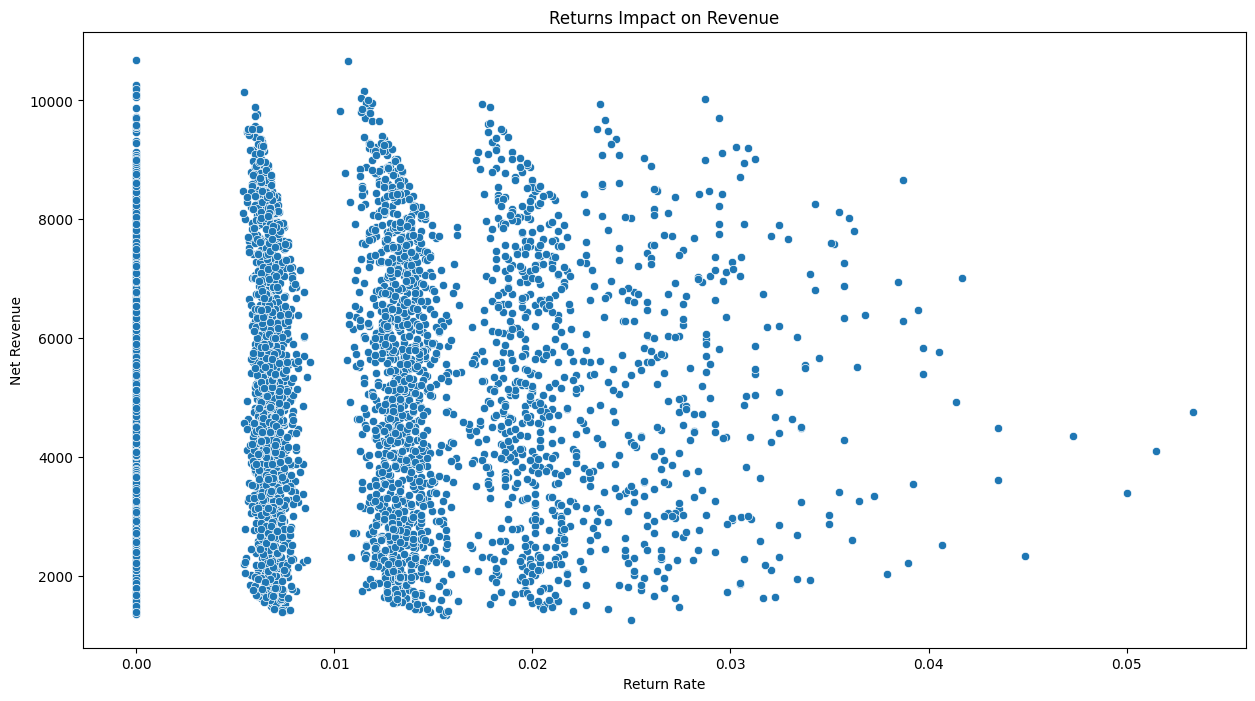

In [25]:
plt.figure(figsize=(15,8))
sns.scatterplot(data=data, x="Return Rate", y="Net Revenue")
plt.title("Returns Impact on Revenue")
plt.xlabel("Return Rate")
plt.ylabel("Net Revenue")
plt.show()

Insight: Higher returns rate barely reduce profitability, and impact is not that severe. 

Decision: Improve product quality. 

# 6. How does revenue change over time?

Text(0, 0.5, 'Net Revenue')

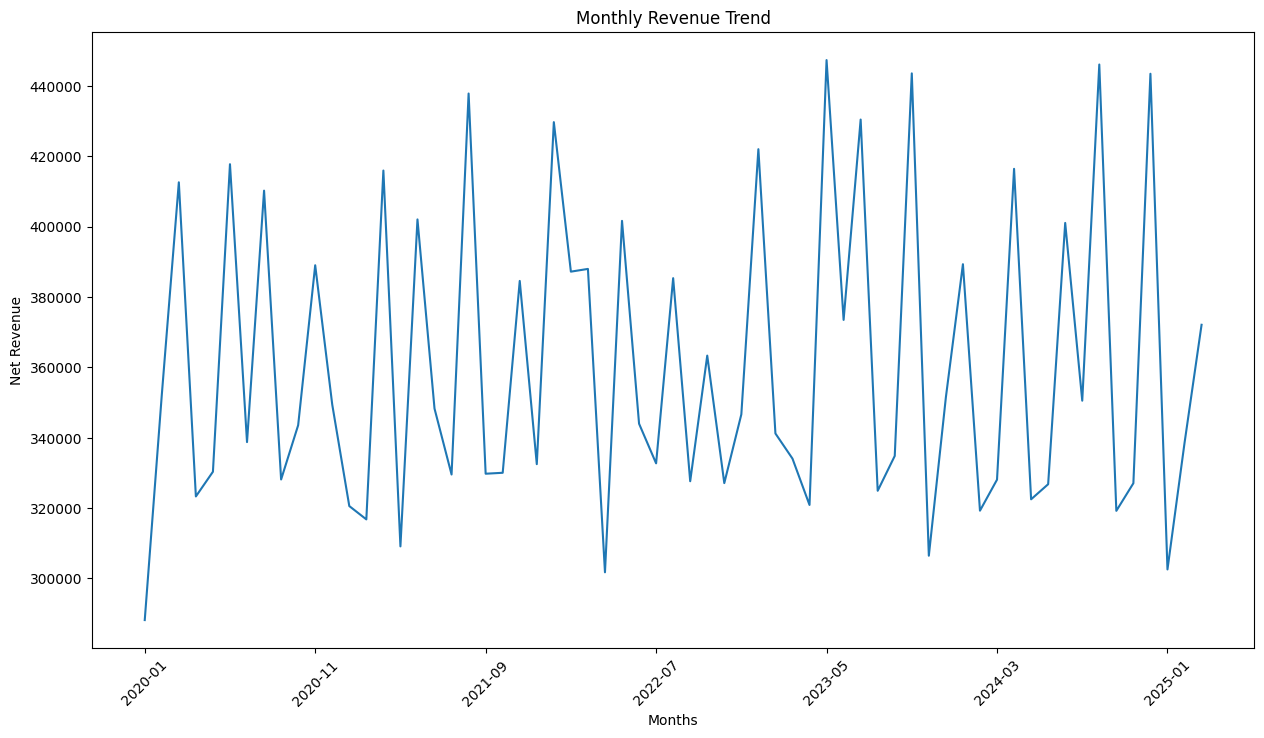

In [27]:
time_revenue = data.groupby("Monthly")["Net Revenue"].sum()

plt.figure(figsize=(15,8))
time_revenue.plot(x="Months", y="Net Revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.xlabel("Months")
plt.ylabel("Net Revenue")

Insight: Revenue shows consistent growth with seasonal spikes, indicating demand cycles. 

Decision: Plan promotions around peak months

# Conclusion 

The business is driven by high-performing products such as Biotin and Zinc from Vitamins and Minerals categories. These products have shown great performance at iHerb. There's limited benefit from discounts. Stategic focus on these areas can significantly improve profitability. 